                                PPROJECT TITLE 
        Promotion Strategy Optimization in Retail Pharmacy 
                     Case Study: COMPANY X(Feb – June 2026)

Excetive  Summary:

This project evaluates the efficiency of promotional strategies within a retail pharmacy environment.

 I focused on identifying categories that are heavily discounted without clear strategic justification, as well as seasonal patterns in discounting behavior.
 
Due to the absence of sales volume data, I reframed the analysis to assess promotional intensity and potential margin risk, using discount depth as a proxy. The goal was to highlight areas where the business may be over-discounting and recommend tighter promotion control to protect profitability.

The outcome is a decision-support framework for improving promotional governance and reducing unnecessary margin exposure.

Project Objectives:

detecting  inefficient promotion structures, and recommend strategies to optimize profitability while maintaining customer traffic.

Company X operates in a highly competitive, price-sensitive environment, where promotions are a key lever to:

Increase store traffic
Expand basket size
Defend market share against competitors

However, without robust optimization, promotions can create a false sense of growth—increasing revenue while silently eroding profitability.

1.Promotion Strategy Diagnostics

-Identifing dominant promotion types (e.g., % discount, bundle, BOGO)

-Evaluating distribution across categories and brands

-Identify categories with excessive promotional exposure

2.Discount Depth analysis

3.Evaluation of Promotion Effectiveness by Product Category

4.Gain Made by Customers vs Loss to Company


    -Customer savings (discount captured)

    -Company revenue sacrificed


Who benefits more — the customer or the business?




Data Constraints Acknowledgment 

Due to the absence of cost and customer-level data, the analysis focuses on proxy indicators of profitability, including:




If provided with a complete dataset, I would reposition the analysis into two strategic pillars: product-centric performance and customer-centric behavior, ensuring both commercial impact and long-term sustainability are addressed.

On the product (or promotion) side, I would reframe the evaluation of promotional effectiveness around three core financial metrics: incremental sales uplift, margin impact, and promotion ROI. The first step would be to construct a robust baseline model to estimate expected sales in the absence of promotions, enabling a clear measurement of true incremental uplift. I would then quantify the margin trade-off by assessing whether the additional revenue generated sufficiently compensates for the discount-driven margin erosion. Building on this, I would implement a structured decision framework (e.g., a performance matrix) to segment promotions into high-performing, neutral, and value-destructive categories. This would allow the business to systematically scale profitable promotions, optimize borderline campaigns, and eliminate those that fail to generate sustainable value.

On the customer side, I would redesign the analysis using an RFM  framework to develop a deeper understanding of customer behavior and loyalty dynamics. This segmentation would help identify high-value loyal customers, promotion-dependent segments, and those at risk of churn. More importantly, it would enable the business to assess price sensitivity and promotion dependency, highlighting which customer groups are likely to disengage if discounts are reduced or removed. These insights can then inform more targeted and personalized promotion strategies, reducing unnecessary discounting while preserving customer retention and lifetime value.

Together, these two perspectives create a more holistic strategy while balancing short-term promotional gains with long-term customer equity and profitability.

In [1524]:
import pandas as pd
import numpy as np

import glob
import os

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px





In [1525]:
def load_files(folder_path):

    df_list = []

    for file in os.listdir(folder_path):

        file_path = os.path.join(r"C:\Users\PAVILION PLUS\Desktop\COMPANY_X   analysis", file)

        try:

            if file.endswith(".csv"):
                df = pd.read_csv(file_path)

            elif file.endswith(".xlsx"):
                df = pd.read_excel(file_path)
            elif file.endswith('.js'):
                df=pd.read_json(file_path)
            elif file.endswith('.txt'):
                df=pd.read_table(file_path)

            else:
                continue

            df['source_file'] = file
            df_list.append(df)

            print(f"{file} loaded successfully")

        except Exception as e:
            print(f"Error loading {file}: {e}")

    return pd.concat(df_list, ignore_index=True)


In [1526]:
df = load_files(r"C:\Users\PAVILION PLUS\Desktop\COMPANY_X   analysis")
df

APRIL.xlsx loaded successfully
FEBRUARY.xlsx loaded successfully
JUNE.xlsx loaded successfully
MARCH.xlsx loaded successfully
MAY.xlsx loaded successfully


,Division,Department,Category,Item Brand,Period,Channel,Group_Code,ITEM,English Description,OFFER TYPE,Price with VAT,Promo Price with VAT,Saving,Depth%,START_DATE,END_DATE,source_file,Hero
0,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103184367,Christian Dior miss dior EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx,NaN
1,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183866,Christian Dior sauvage Perfume 200 ml,Direct_Discount,1054.57,843.70,210.0,0.200000,2026-04-01,2026-04-30,APRIL.xlsx,NaN
2,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183807,Christian Dior pure poison EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx,NaN
3,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103181908,Christian Dior dior homme intense EDP150 ml,Direct_Discount,725.86,580.70,145.0,0.200000,2026-04-01,2026-04-30,APRIL.xlsx,NaN
4,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183129,Christian Dior hypnotic poison EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37489,WELLNESS,NUTRACEUTICALS AND NUTRITION,SPORTS AND FITNESS,Born Winner,Full,BM only,1_230589,102476747,Bw Mega Pro Protein Bar Waffle With Chocolate ...,BUY 1 GET 1 WITH PERCENT OFF 50,30.03,22.55,7.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL
37490,WELLNESS,NUTRACEUTICALS AND NUTRITION,HEALTHY NUTRITION,True Honey,Full,BM only,1_230589,103379017,Manuka Truehoney Rare Harvest Mgo 2050 - 230 Gm,BUY 1 GET 1 WITH PERCENT OFF 50,10041.65,7531.25,2510.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL
37491,WELLNESS,NUTRACEUTICALS AND NUTRITION,SPORTS AND FITNESS,Eric Favre,Full,BM only,1_230589,102028709,Eric Favre Mass Gainer Vanille 3kg,BUY 1 GET 1 WITH PERCENT OFF 50,401.10,300.85,100.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL
37492,WELLNESS,NUTRACEUTICALS AND NUTRITION,SPORTS AND FITNESS,Born Winner,Full,BM only,1_230589,102476712,Bw Keto Bar Italian Creme 60 Gm,BUY 1 GET 1 WITH PERCENT OFF 50,27.38,20.55,6.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL


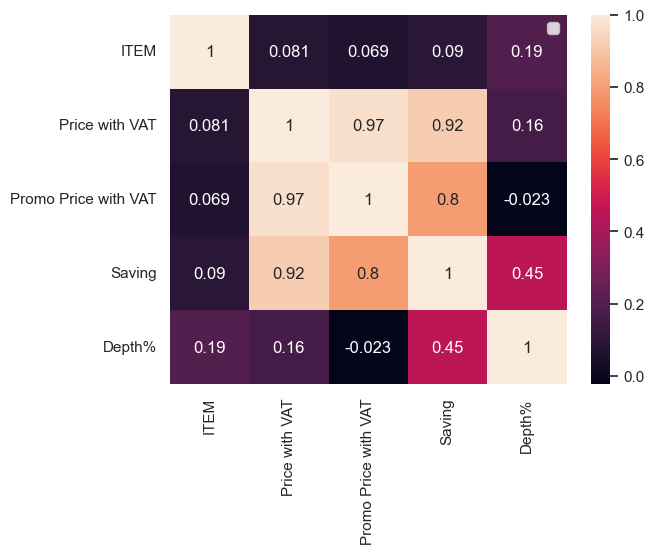

In [1527]:
data_corr=df.corr(numeric_only=True)
sns.heatmap(data_corr,annot=True)
plt.legend('numerical correction')
plt.show()

In [1528]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors='coerce')

FEATURE ENGINEERING

In [1529]:
#Promotion Duration
df['Promo_Duration'] = (df['END_DATE'] - df['START_DATE']).dt.days

#Discount Percentage
df['Calculated_Discount'] = (df['Price with VAT'] - df['Promo Price with VAT']) / df['Price with VAT']*100

#Price Reduction
df['Price_Reduction'] = df['Price with VAT'] - df['Promo Price with VAT']

#Discount Depth
df['Discount_Depth'] = df['Saving'] / df['Price with VAT'] 

#Price Category
df['Price_Category'] = pd.qcut(df['Price with VAT'], q=4, labels=['Low','Medium','High','Premium'])

#calculated distance category
df['Calculated_Discount_catrgory']  = pd.qcut(df['Calculated_Discount'], q=3, labels=['Low','High','Premium'])

#Promotion Month
df['Promo_Month'] = df['START_DATE'].dt.month



#corrected_Depth%
mapping = {
    'BUY 2 GET 1 FREE ': 0.33,                    # 1 free / 3 total
    'BUY 1 GET 1 FREE ': 0.50,                    # 1 free / 2 total
    'BUY 2 GET 2 FREE ': 0.50,                    # 2 free / 4 total
    'BUY 1 GET 1 WITH PERCENT OFF 30': 0.15,     # (1 * 0.30) / 2 total
    'BUY 1 GET 1 WITH PERCENT OFF 40': 0.20,     # (1 * 0.40) / 2 total
    'BUY 1 GET 1 WITH PERCENT OFF 50': 0.25,     # (1 * 0.50) / 2 total
    'BUY 1 GET 1 WITH PERCENT OFF 60': 0.30,     # (1 * 0.60) / 2 total
    'BUY 1 GET 1 WITH PERCENT OFF 70': 0.35,     # (1 * 0.70) / 2 total
    'BUY 1 GET 2 FREE ': 0.67,                    # 2 free / 3 total
    '(B/G) BUY 2 GET 1 FREE ': 0.33               # 1 free / 3 total
}
#this mapping assumes equal-value items and that the discount applies to the entire purchase. Adjustments may be needed for different scenarios.

df["corrected_Depth%"] = df.apply( lambda row: mapping[row["OFFER TYPE"]] if row["OFFER TYPE"] in mapping else row["Depth%"], axis=1)

# Promotion Risk Score
df['Promo_Risk_Score'] = df['corrected_Depth%'] * df['Promo_Duration']

#LABELS
mapping = {
    'Accez':'PL',
    'Active Go':'PL',
    'Alfoshan':'PL',
    'ALmisan':'PL', 
    'AURI':'PL',
    'Babygee':'PL',
    'Babywell':'PL',
    'Beatswell':'PL',
    'Bibi':'PL',
    'Bio-Synergy':'PL',
    'Blade':'PL',
    'Body Spa':'PL',
    'BODYLICIOUS':'PL',
    'Boutique':'PL',
    'Citizen':'PL',
    'Clary':'PL',
    'Clevie':'PL',
    'Clevie Derma':'PL',
    'Connect':'PL',
    'COXIR':'PL',
    'Creigtons':'PL',
    'Davids':'PL',
    'Emotion':'PL',
    'Eric Favre':'PL',
    'Febella':'PL',
    'First Aids Kit':'PL',
    'Footness':'PL',
    'Fragrances For Her':'PL',
    'Fruit Works':'PL',
    'Gamar':'PL',
    'Grit':'PL',
    'I Kuzma':'PL',
    'Kaiyang':'PL',
    'Keller':'PL',
    'Killys':'PL',
    'Mades':'PL',
    'Martini':'PL',
    'Medex':'PL',
    'Molfix':'PL',
    'Movera':'PL',
    'Movera Ortho':'PL',
    'Movera Sport':'PL',
    'MUVU':'PL',
    'Nahdi':'PL',
    'NUTSHELL':'PL',
    'OE':'PL',
    'OnCall':'PL',
    'Orex':'PL',
    'Parsa':'PL',
    'Parsa Beauty':'PL',
    'Qure':'PL',
    'Rosal':'PL',
    'Sanotact':'PL',
    'Shadez':'PL',
    'True Honey':'PL',
    'Velveta':'PL',
    'Viora':'PL',
    'Yunmai':'PL',
    'Yuwell':'PL',
    'ZAK':'PL'

}
df["LABELS"] = df.apply( lambda row: mapping[row["Item Brand"]] if row["Item Brand"] in mapping else 'OTHERS', axis=1)


DETAILING OF OBJECTIVES

# OBJECTIVE 1.Promotion Strategy Diagnostics

Promotion Types Distribution
OFFER TYPE
Direct_Discount                    29.188670
BUY 2 GET 1 FREE                   23.267723
BUY 1 GET 1 FREE                   16.906705
BUY 1 GET 1 WITH PERCENT OFF 50    10.439004
BUY 1 GET 1 WITH PERCENT OFF 40     9.038780
BUY 2 GET 2 FREE                    8.326666
BUY 1 GET 1 WITH PERCENT OFF 30     1.546914
BUY 1 GET 2 FREE                    0.786793
BUY 1 GET 1 WITH PERCENT OFF 60     0.426735
(B/G) BUY 2 GET 1 FREE              0.045341
BUY 1 GET 1 WITH PERCENT OFF 70     0.026671
Name: proportion, dtype: float64


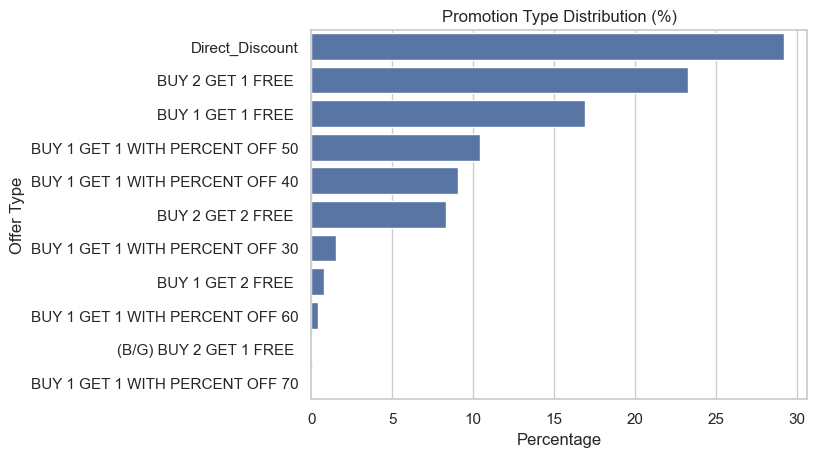

In [1530]:
#1.1 Dominant Promotion Types
promo_dist = df['OFFER TYPE'].value_counts(normalize=True) * 100
print('Promotion Types Distribution')
print(promo_dist)

sns.barplot(x=promo_dist.values, y=promo_dist.index)
plt.title("Promotion Type Distribution (%)")
plt.xlabel("Percentage")
plt.ylabel("Offer Type")
plt.show()

In [1531]:
#1.2
promo_dist_month = df.groupby('Promo_Month')['OFFER TYPE'].value_counts(normalize=True) * 100
promo_dist_month

Promo_Month  OFFER TYPE                     
2            BUY 2 GET 1 FREE                   27.146320
             BUY 2 GET 2 FREE                   24.837352
             Direct_Discount                    20.653145
             BUY 1 GET 1 FREE                   19.874984
             BUY 1 GET 1 WITH PERCENT OFF 50     5.931879
             BUY 1 GET 1 WITH PERCENT OFF 30     0.650593
             BUY 1 GET 1 WITH PERCENT OFF 60     0.331675
             BUY 1 GET 2 FREE                    0.306162
             (B/G) BUY 2 GET 1 FREE              0.140324
             BUY 1 GET 1 WITH PERCENT OFF 70     0.127567
3            Direct_Discount                    30.292490
             BUY 1 GET 1 WITH PERCENT OFF 40    25.849802
             BUY 1 GET 1 WITH PERCENT OFF 50    18.134387
             BUY 2 GET 1 FREE                   16.079051
             BUY 1 GET 1 FREE                    8.537549
             BUY 1 GET 2 FREE                    0.474308
             BUY 1 GET 1 WI

In [1532]:
#1.3
promo_dist_month_labels = df.groupby(['LABELS','Promo_Month'])['OFFER TYPE'].value_counts(normalize=True) * 100
promo_dist_month_labels

LABELS  Promo_Month  OFFER TYPE                     
OTHERS  2            BUY 2 GET 1 FREE                   31.775422
                     BUY 2 GET 2 FREE                   29.072719
                     Direct_Discount                    18.605346
                     BUY 1 GET 1 FREE                   12.154696
                     BUY 1 GET 1 WITH PERCENT OFF 50     6.809019
                     BUY 1 GET 1 WITH PERCENT OFF 30     0.761535
                     BUY 1 GET 1 WITH PERCENT OFF 60     0.388234
                     BUY 1 GET 2 FREE                    0.358369
                     (B/G) BUY 2 GET 1 FREE              0.074660
        3            BUY 1 GET 1 WITH PERCENT OFF 40    31.273910
                     Direct_Discount                    29.648049
                     BUY 2 GET 1 FREE                   19.452946
                     BUY 1 GET 1 FREE                    9.429992
                     BUY 1 GET 1 WITH PERCENT OFF 50     8.856159
                     BU

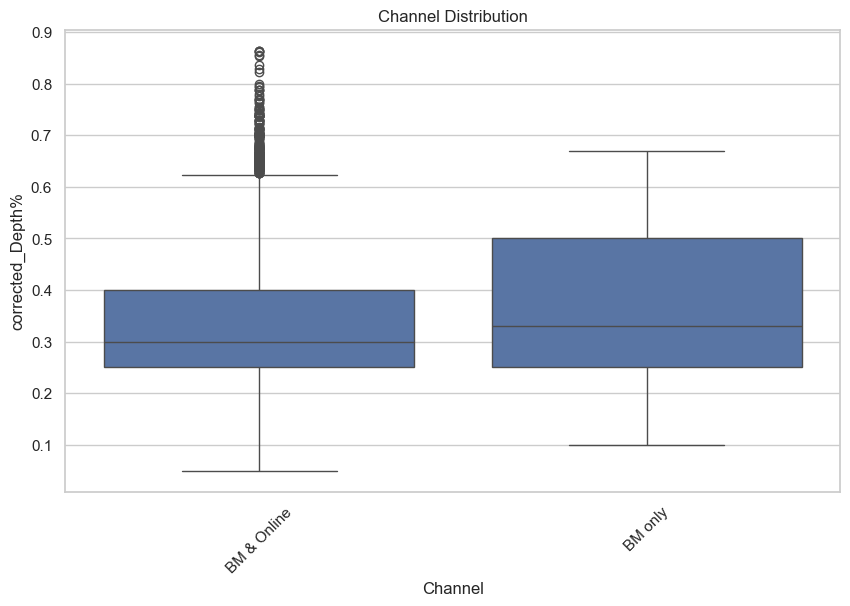

In [1533]:
#1.4
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Channel', y='corrected_Depth%')
plt.title("Channel Distribution")
plt.xticks(rotation=45)
plt.show()

In [1534]:
#1.5 Distribution Across Categories & Brands

category_promo = pd.crosstab(df['Category'], df['OFFER TYPE'], normalize='index') * 100
brand_promo = pd.crosstab(df['Item Brand'], df['OFFER TYPE'], normalize='index') * 100

print(category_promo)


OFFER TYPE               (B/G) BUY 2 GET 1 FREE   BUY 1 GET 1 FREE   \
Category                                                              
ADVANCED ORAL CARE                      0.000000          26.000000   
BABY FOOD                               0.000000           0.000000   
BABY MILK                               0.000000           0.000000   
BABY TOILETRIES                         0.000000           2.645503   
BABY WIPES                              0.000000           0.000000   
BATH AND SHOWER                         0.000000          32.051282   
BEAUTY ACCESSORIES                      0.000000          39.940719   
BEAUTY SKIN CARE                        0.000000          23.308271   
BODY FRESHENERS                         0.000000          52.333333   
BODY MOISTURIZERS                       0.000000          44.112150   
BODY SUPPORT                            0.000000           0.000000   
BREATH FRESHENER                        0.000000          10.810811   
CLEAN 

In [1535]:
print(brand_promo)

OFFER TYPE      (B/G) BUY 2 GET 1 FREE   BUY 1 GET 1 FREE   \
Item Brand                                                   
21St Century                        0.0          41.666667   
7Elements                           0.0          33.333333   
ACM                                 0.0          49.565217   
ADDITIVA                            0.0           0.000000   
ALPECIN                             0.0           0.000000   
...                                 ...                ...   
ZAK                                 0.0          60.000000   
ZO Skin Health                      0.0          33.333333   
Zartaux                             0.0          20.000000   
Zerostat                            0.0           0.000000   
olaplex                             0.0         100.000000   

OFFER TYPE      BUY 1 GET 1 WITH PERCENT OFF 30  \
Item Brand                                        
21St Century                                0.0   
7Elements                               

In [1536]:
#1.6 Over-Reliance on Margin-Eroding Promotions

high_discount_threshold = df['corrected_Depth%'].quantile(0.75)

high_discount_ratio = (
    df[df['corrected_Depth%'] > high_discount_threshold]
    .groupby('Category')
    .size() / df.groupby('Category').size()
).fillna(0)

print(high_discount_ratio.sort_values(ascending=False))

Category
COUGH COLD AND ALLERGY     0.483871
FRAGRANCES                 0.287307
MEN GROOMING               0.119403
NON FEEDING ACCESSORIES    0.110127
HAIR COLOR                 0.078740
HEALTHY NUTRITION          0.070621
SPORTS AND FITNESS         0.061420
TOOTHBRUSHES               0.037838
BATH AND SHOWER            0.033800
HAIR REMOVALS              0.032028
GENERAL HEALTH             0.026099
MEDICAL DEVICES            0.026042
CLEAN HAIR CARE            0.020725
MEN HEALTH                 0.019830
ELECTRICAL HAIR TOOLS      0.019231
WOMEN HEALTH               0.019209
BEAUTY SKIN CARE           0.018006
PROFESSIONAL HAIR CARE     0.012158
HAIR TREATMENT             0.009677
DERMO SKIN CARE            0.008825
WOUND CARE                 0.008489
REGULAR SKIN CARE          0.007160
ELDERLY CARE               0.006061
TOOTHPASTE                 0.004587
DEODORANTS                 0.001582
DAILY HAIR CARE            0.001170
BREATH FRESHENER           0.000000
BODY SUPPORT       

In [1537]:
#1.7  CATEGORY-LEVEL ANALYSIS

category_analysis = df.groupby('Category').agg({
    'corrected_Depth%': 'mean',
    'Promo_Risk_Score': 'mean',
    'ITEM': 'count'
}).rename(columns={'ITEM': 'Promo_Frequency'}).reset_index().sort_values(by='Promo_Risk_Score', ascending=False)

category_analysis 

,Category,corrected_Depth%,Promo_Risk_Score,Promo_Frequency
40,MEN HAIR COLOR,0.454783,13.253043,23
13,COUGH COLD AND ALLERGY,0.449677,13.051290,31
39,MEN GROOMING,0.447029,12.990995,67
24,FRAGRANCES,0.424533,12.228722,1883
47,PAIN MANAGEMENT,0.417500,12.148929,28
44,NAILS,0.430383,12.128224,679
16,DERMA CARE,0.409091,11.863636,11
5,BATH AND SHOWER,0.397700,11.517840,858
32,HOME LIFESTYLE,0.400000,11.500000,60
12,CLEAN HAIR CARE,0.392902,11.436695,193


In [1538]:
#1.8 Sort by risk
category_analysis = category_analysis.sort_values(by='Promo_Risk_Score', ascending=False)

print("\n=== CATEGORY PROMOTION ANALYSIS ===")
print(category_analysis.head(10))


=== CATEGORY PROMOTION ANALYSIS ===
                  Category  corrected_Depth%  Promo_Risk_Score  \
40          MEN HAIR COLOR          0.454783         13.253043   
13  COUGH COLD AND ALLERGY          0.449677         13.051290   
39            MEN GROOMING          0.447029         12.990995   
24              FRAGRANCES          0.424533         12.228722   
47         PAIN MANAGEMENT          0.417500         12.148929   
44                   NAILS          0.430383         12.128224   
16              DERMA CARE          0.409091         11.863636   
5          BATH AND SHOWER          0.397700         11.517840   
32          HOME LIFESTYLE          0.400000         11.500000   
12         CLEAN HAIR CARE          0.392902         11.436695   

    Promo_Frequency  
40               23  
13               31  
39               67  
24             1883  
47               28  
44              679  
16               11  
5               858  
32               60  
12              

In [1539]:
#1.9 concept of carnibalization in the analysis

# 1. The use of  'median' instead of 'mean' to protect against Month 2's crazy numbers
item_metrics = df.groupby('ITEM').agg(
    unique_months=('Promo_Month', 'nunique'),
    avg_discount=('corrected_Depth%', 'median')  # <-- CHANGED TO MEDIAN
).reset_index()

# 2. Get dynamic thresholds from the item-level summary
# (Top 25% of items by frequency, and Top 25% of items by average depth)
freq_threshold = item_metrics['unique_months'].quantile(0.75)
depth_threshold = item_metrics['avg_discount'].quantile(0.75)

# 3. Filter the summary dataframe for items that exceed BOTH thresholds
cannibal_items = item_metrics[
    (item_metrics['unique_months'] >= freq_threshold) & 
    (item_metrics['avg_discount'] >= depth_threshold)
]['ITEM']

# 4. Map the flag back to your original dataframe
df['Cannibalization_Risk_Flag'] = df['ITEM'].isin(cannibal_items).astype(int)

# 5. Quick check to see how many items were flagged
print(f"Number of flagged items: {df['Cannibalization_Risk_Flag'].sum()}")

Number of flagged items: 3998


In [1540]:
#2.0 Select the columns you want to inspect
columns_to_show = ['ITEM', 'English Description', 'Category', 'corrected_Depth%', 'Promo_Month']

# Filter and display the unique combinations
flagged_details = df[df['Cannibalization_Risk_Flag'] == 1][columns_to_show].drop_duplicates(subset=['ITEM'])

# Display the dataframe
print(flagged_details)


           ITEM                                English Description  \
647   101747779          Almisan Gel With Devil'S Claw 250ml (Jar)   
648   101747787             Almisan Horse Balm Cooling 250ml (Jar)   
649   102040097   Beatswell Eucalyptus And Menthol Lozenges 36 Pcs   
650   102040089      Beatswell Lemon And Balm Mint Lozenges 36 Pcs   
651   102040100      Beatswell Sweeteners And Saga Lozenges 36 Pcs   
...         ...                                                ...   
6780  102234692  Beatswell Vitamin C + Zinc 20 Effervescent Tab...   
6781  102209657  Beatswell Iron + Vitamin C 20 Effervescent Tab...   
6783  102499615  Beatswell Calcium + Mg + D3 15 Effervescent Ta...   
6784  102525668  Beatswell Multivitamin Energy 20 Effervescent ...   
6792  102209673     Beatswell Multivitamin 20 Effervescent Tablets   

                    Category  corrected_Depth%  Promo_Month  
647          PAIN MANAGEMENT               0.5            4  
648          PAIN MANAGEMENT       

In [1541]:
#2.1 Export the flagged details to an Excel file
flagged_details.to_csv('cannibalization_risk_items.csv', index=False)
print("Saved flagged items to 'cannibalization_risk_items.csv'")

Saved flagged items to 'cannibalization_risk_items.csv'


In [1542]:
#2.2 Check the average discount depth per month
print("Average Discount Depth by Month:")
print(df.groupby('Promo_Month')['corrected_Depth%'].mean())

# Check how many unique items were discounted in each month
print("\nNumber of Unique Items Discounted by Month:")
print(df.groupby('Promo_Month')['ITEM'].nunique())

Average Discount Depth by Month:
Promo_Month
2    0.401254
3    0.298935
4    0.330450
5    0.295876
6    0.398416
Name: corrected_Depth%, dtype: float64

Number of Unique Items Discounted by Month:
Promo_Month
2    7677
3    6325
4    6777
5    7105
6    8835
Name: ITEM, dtype: int64


In [1543]:
# 2.3. Filtering of  the dataframe to ONLY show  flagged risk items
flagged_df = df[df['Cannibalization_Risk_Flag'] == 1]

# 2. Pivot the data to see how these specific items are spread across months
monthly_distribution = flagged_df.groupby('Promo_Month')['ITEM'].count()

print("--- Distribution of Flagged Items Across All Months ---")
print(monthly_distribution)

--- Distribution of Flagged Items Across All Months ---
Promo_Month
2    783
3    769
4    769
5    908
6    769
Name: ITEM, dtype: int64


In [1544]:
# 2.4. Filter for rows matching our flagged items
flagged_df = df[df['Cannibalization_Risk_Flag'] == 1]

# 2. Group by ITEM to find those that appear in Months 2, 3,4,5,6
# (We filter for items that have a count of 3 or more across those specific months)
core_months = [2,3, 4,5,6]
core_flagged_df = flagged_df[flagged_df['Promo_Month'].isin(core_months)]
item_month_counts = core_flagged_df.groupby('ITEM')['Promo_Month'].nunique()

core_item_ids = item_month_counts[item_month_counts == len(core_months)].index

# 3. Extract clean details for these 1444 items
columns_to_extract = ['Division', 'Department', 'Category', 'Item Brand', 'ITEM', 'English Description']
chronic_offenders = df[df['ITEM'].isin(core_item_ids)][columns_to_extract].drop_duplicates(subset=['ITEM'])

# 4. View the total and the first few items
print(f"Successfully extracted {len(chronic_offenders)} core chronic items.")
print("\nFirst 10 Chronic Offenders:")
print(chronic_offenders.head(10))

Successfully extracted 769 core chronic items.

First 10 Chronic Offenders:
         Division              Department                Category Item Brand  \
647      MEDICINE        SELF MEDICATIONS         PAIN MANAGEMENT    Almisan   
648      MEDICINE        SELF MEDICATIONS         PAIN MANAGEMENT    Almisan   
649      MEDICINE        SELF MEDICATIONS  COUGH COLD AND ALLERGY  Beatswell   
650      MEDICINE        SELF MEDICATIONS  COUGH COLD AND ALLERGY  Beatswell   
651      MEDICINE        SELF MEDICATIONS  COUGH COLD AND ALLERGY  Beatswell   
737  MOM AND BABY  BABY DIAPERS AND PANTS         REGULAR DIAPERS      Gamar   
738  MOM AND BABY  BABY DIAPERS AND PANTS          TRAINING PANTS      Gamar   
739  MOM AND BABY  BABY DIAPERS AND PANTS         REGULAR DIAPERS      Gamar   
740  MOM AND BABY  BABY DIAPERS AND PANTS         REGULAR DIAPERS      Gamar   
741  MOM AND BABY  BABY DIAPERS AND PANTS         REGULAR DIAPERS      Gamar   

          ITEM                             

In [1545]:
#2.5
chronic_offenders.to_csv('chronic_promo_offenders_769.csv', index=False)

In [1546]:
# Count how many distinct high-risk months each unique item accumulates
item_persistence = flagged_df.groupby('ITEM')['Promo_Month'].nunique().reset_index()
item_persistence.columns = ['ITEM', 'Months_at_High_Risk']

# See the distribution of persistence across your assortment
persistence_distribution = item_persistence['Months_at_High_Risk'].value_counts().sort_index()

print("--- How many months do items spend at High Risk? ---")
print(persistence_distribution)

--- How many months do items spend at High Risk? ---
Months_at_High_Risk
5    769
Name: count, dtype: int64


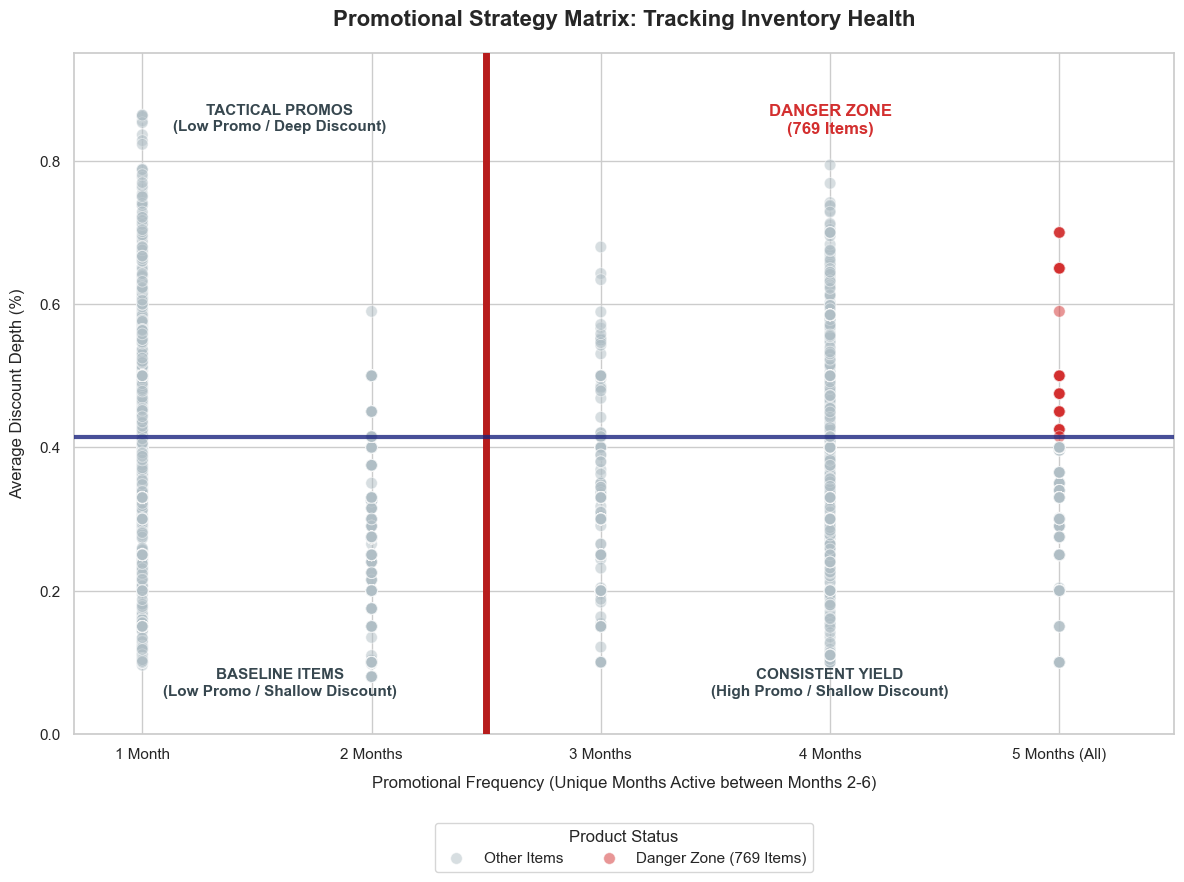

In [1547]:

# 1. Prepare the plotting data using our previous item_metrics dataframe
plot_data = item_metrics.copy()

# FORCE the chart to look ONLY at your strict 769 item list for the red color mapping
danger_label = 'Danger Zone (769 Items)'
plot_data['Quadrant_Label'] = 'Other Items'
plot_data.loc[plot_data['ITEM'].isin(core_item_ids), 'Quadrant_Label'] = danger_label

# Define your exact visual thresholds
freq_threshold = 2.5
depth_threshold = 0.415  

# 2. Set up the plotting style
plt.figure(figsize=(12, 9))
sns.set_theme(style="whitegrid")

# 3. Create the scatter plot
ax = sns.scatterplot(
    data=plot_data,
    x='unique_months',
    y='avg_discount',
    hue='Quadrant_Label',
    palette={'Other Items': '#b0bec5', danger_label: '#d32f2f'},  # Keeps only your 769 red
    alpha=0.5,
    s=70,
    zorder=3 
)

# Set clean, strict limits on the axes to prevent text clipping
plt.ylim(0, 0.95)
plt.xlim(0.7, 5.5)  

# 4. FIXED DEMARCATION LINES
# Vertical separator at 2.5 months (extra bold, solid red)
ax.axvline(x=2.5, color='#b71c1c', linestyle='-', linewidth=5, alpha=1.0, zorder=5)

# Horizontal separator at your depth threshold (solid dark blue)
ax.axhline(y=depth_threshold, color='#1a237e', linestyle='-', linewidth=3, alpha=0.8, zorder=5)

# 5. LOCKED TEXT COORDINATES (Strictly hardcoded to match your 769 KPI text)
# Danger Zone (Top Right)
plt.text(4.0, 0.88, "DANGER ZONE\n(769 Items)", 
         color='#d32f2f', fontsize=12, weight='bold', ha='center', va='top', zorder=6)

# Tactical Promos (Top Left)
plt.text(1.6, 0.88, "TACTICAL PROMOS\n(Low Promo / Deep Discount)", 
         color='#37474f', fontsize=11, weight='bold', ha='center', va='top', zorder=6)

# Consistent Yield (Bottom Right)
plt.text(4.0, 0.05, "CONSISTENT YIELD\n(High Promo / Shallow Discount)", 
         color='#37474f', fontsize=11, weight='bold', ha='center', va='bottom', zorder=6)

# Baseline Items (Bottom Left)
plt.text(1.6, 0.05, "BASELINE ITEMS\n(Low Promo / Shallow Discount)", 
         color='#37474f', fontsize=11, weight='bold', ha='center', va='bottom', zorder=6)

# 6. Final chart formatting
plt.title("Promotional Strategy Matrix: Tracking Inventory Health", fontsize=16, pad=20, weight='bold')
plt.xlabel("Promotional Frequency (Unique Months Active between Months 2-6)", fontsize=12, labelpad=10)
plt.ylabel("Average Discount Depth (%)", fontsize=12, labelpad=10)

# Ticks match numeric data (1-5 months), while labels clarify the duration context
plt.xticks(
    ticks=[1.0, 2.0, 3.0, 4.0, 5.0], 
    labels=['1 Month', '2 Months', '3 Months', '4 Months', '5 Months (All)']
)

# Clean up legend positioning below the graph axis
plt.legend(title="Product Status", loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=11)

plt.tight_layout()

# Save the plot image cleanly without layout clipping
plt.savefig('promotional_danger_zone_matrix_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

# OBJECTIVE 2.Discount Depth 

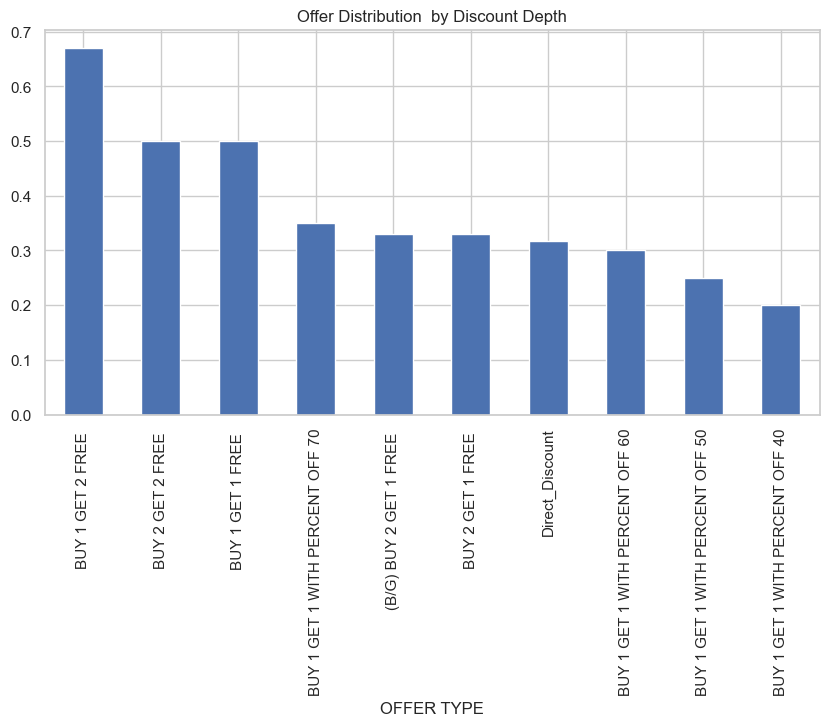

In [1548]:
#2.1 discounting depth as per offer type
offer_distribution = (
    df.groupby('OFFER TYPE')['corrected_Depth%']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

offer_distribution.plot(kind='bar', figsize=(10,5), title='Offer Distribution  by Discount Depth')
plt.show()

In [1549]:
#2.1 IDENTIFY OVER-PROMOTED CATEGORIES
# Thresholds 
high_discount_threshold = df['corrected_Depth%'].quantile(0.75)
high_frequency_threshold = category_analysis['Promo_Frequency'].quantile(0.75)

category_analysis['Risk_Level'] = np.where(
    (category_analysis['corrected_Depth%'] > high_discount_threshold) &
    (category_analysis['Promo_Frequency'] > high_frequency_threshold),
    'Critical',
    np.where(
        (category_analysis['corrected_Depth%'] > high_discount_threshold),
        'Moderate',
        'Low'
    )
)

print("\n=== RISK CLASSIFICATION ===")
print(category_analysis[['Category', 'Risk_Level']].head(10))





=== RISK CLASSIFICATION ===
                  Category Risk_Level
40          MEN HAIR COLOR        Low
13  COUGH COLD AND ALLERGY        Low
39            MEN GROOMING        Low
24              FRAGRANCES        Low
47         PAIN MANAGEMENT        Low
44                   NAILS        Low
16              DERMA CARE        Low
5          BATH AND SHOWER        Low
32          HOME LIFESTYLE        Low
12         CLEAN HAIR CARE        Low


In [1550]:
# DECISION FRAMEWORK

def decision_rule(row):
    if row['Risk_Level'] == 'Critical':
        return 'Reduce or Stop Promotions'
    elif row['Risk_Level'] == 'Moderate':
        return 'Optimize Discount Strategy'
    else:
        return 'Maintain Strategy'

category_analysis['Recommended_Action'] = category_analysis.apply(decision_rule, axis=1)

print("\n=== FINAL RECOMMENDATIONS ===")
print(category_analysis[['Category', 'Risk_Level', 'Recommended_Action']])


=== FINAL RECOMMENDATIONS ===
                   Category Risk_Level Recommended_Action
40           MEN HAIR COLOR        Low  Maintain Strategy
13   COUGH COLD AND ALLERGY        Low  Maintain Strategy
39             MEN GROOMING        Low  Maintain Strategy
24               FRAGRANCES        Low  Maintain Strategy
47          PAIN MANAGEMENT        Low  Maintain Strategy
44                    NAILS        Low  Maintain Strategy
16               DERMA CARE        Low  Maintain Strategy
5           BATH AND SHOWER        Low  Maintain Strategy
32           HOME LIFESTYLE        Low  Maintain Strategy
12          CLEAN HAIR CARE        Low  Maintain Strategy
8           BODY FRESHENERS        Low  Maintain Strategy
9         BODY MOISTURIZERS        Low  Maintain Strategy
46                  OPTICAL        Low  Maintain Strategy
37                   MAKEUP        Low  Maintain Strategy
6        BEAUTY ACCESSORIES        Low  Maintain Strategy
29             HAND HYGIENE        Low  M

# OBJECTIVE 3.Evaluation of Promotion Effectiveness by Product Category

In [1551]:
df.groupby('LABELS').agg({'corrected_Depth%':'sum','Saving':'sum','Promo Price with VAT':'mean'})

,corrected_Depth%,Saving,Promo Price with VAT
LABELS,,,
OTHERS,10844.076973,3310912.0,181.580697
PL,2236.531511,200196.0,63.318114


In [1552]:
df.groupby(['LABELS','OFFER TYPE'])['OFFER TYPE'].count()

LABELS  OFFER TYPE                     
OTHERS  (B/G) BUY 2 GET 1 FREE                5
        BUY 1 GET 1 FREE                   4224
        BUY 1 GET 1 WITH PERCENT OFF 30     580
        BUY 1 GET 1 WITH PERCENT OFF 40    3389
        BUY 1 GET 1 WITH PERCENT OFF 50    2530
        BUY 1 GET 1 WITH PERCENT OFF 60     160
        BUY 1 GET 2 FREE                    289
        BUY 2 GET 1 FREE                   8479
        BUY 2 GET 2 FREE                   3122
        Direct_Discount                    8792
PL      (B/G) BUY 2 GET 1 FREE               12
        BUY 1 GET 1 FREE                   2115
        BUY 1 GET 1 WITH PERCENT OFF 50    1384
        BUY 1 GET 1 WITH PERCENT OFF 70      10
        BUY 1 GET 2 FREE                      6
        BUY 2 GET 1 FREE                    245
        Direct_Discount                    2152
Name: OFFER TYPE, dtype: int64

In [1553]:
# Compare Deep Discount exposure (>35%) between Private Label and National Brands
pl_vs_others = pd.crosstab(df['LABELS'], df['corrected_Depth%'] > 0.35, normalize='index') * 100
print("Deep Discount Exposure Matrix by Brand Type:")
print(pl_vs_others)

Deep Discount Exposure Matrix by Brand Type:
corrected_Depth%      False      True 
LABELS                                
OTHERS            65.489389  34.510611
PL                48.582039  51.417961


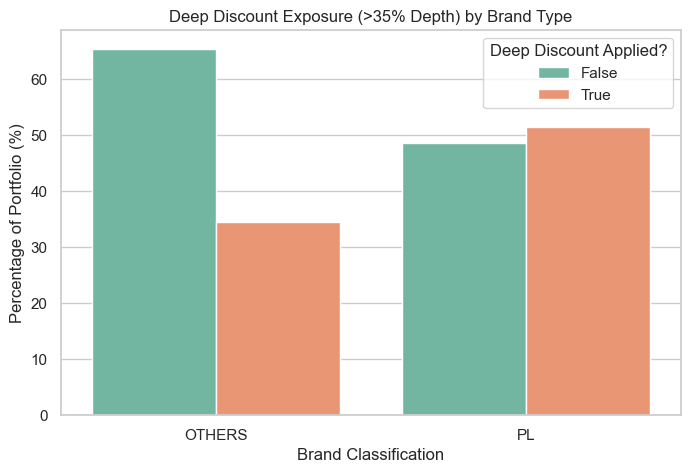

In [1554]:
# Code to inject into your notebook for a polished visual
exposure_df = pl_vs_others.reset_index()
exposure_df_melted = pd.melt(exposure_df, id_vars=['LABELS'], value_vars=[False, True],
                             var_name='Deep_Discount', value_name='Percentage')

plt.figure(figsize=(8, 5))
sns.barplot(data=exposure_df_melted, x='LABELS', y='Percentage', hue='Deep_Discount', palette='Set2')
plt.title("Deep Discount Exposure (>35% Depth) by Brand Type")
plt.ylabel("Percentage of Portfolio (%)")
plt.xlabel("Brand Classification")
plt.legend(title="Deep Discount Applied?")
plt.show()




# Key Metrics Explained
# The X-Axis (Brand Classification): Groups the pharmacy's products into National Brands (OTHERS) and Private Label (PL).

# The Y-Axis (Percentage of Portfolio): Shows what share of that brand type's total product assortment falls into each discount category.

# The Legend (Deep Discount Applied?):

# Orange (True): Products deeply discounted by more than 35%.

# Green (False): Products with normal, shallow, or no discounts (35% or less).

# 2. Core Insight & Business Takeaway
# The chart exposes a significant structural risk in the company's promotional strategy:

# Private Label (PL) Behavior (Right): Over half (51.4%) of Private Label items are deeply discounted. 
# In retail pharmacy, this is generally a healthy strategy because private labels carry massive profit margins.
#  The business can afford to slash these prices to drive foot traffic.

# National Brands / OTHERS Behavior (Left): Over a third (34.5%) of external national brands are receiving deep discounts.
#  This is the danger zone. External brands have thin profit margins due to manufacturer costs. 
# Discounting them by more than 35% means the pharmacy is highly likely selling them at a loss, resulting in severe margin leakage.

# OBJECTIVE 4.Gain Made by Customers vs Loss to Company

In [1555]:
#4.1 Customer Savings

total_customer_savings = df['Saving'].sum()

print('Customer Savings:')
print(total_customer_savings)

Customer Savings:
3511108.0


In [1556]:
total_customer__monthly_savings = df.groupby('Promo_Month')['Saving'].sum()
total_customer__monthly_savings



Promo_Month
2     869627.0
3     475654.0
4     559369.0
5     538153.0
6    1068305.0
Name: Saving, dtype: float64

In [1557]:
#4.2 Company Revenue Sacrifice
total_revenue_sacrifice = (df['Price with VAT'] - df['Promo Price with VAT']).sum()
print('total_revenue_sacrifice:')
print(total_revenue_sacrifice) 

total_revenue_sacrifice:
3532705.6899999995


In [1558]:
#4.3 Net Value Transfer
value_transfer = pd.DataFrame({
    'Metric': ['Customer Gain', 'Company Loss'],
    'Value': [total_customer_savings, total_revenue_sacrifice]
})

print(value_transfer)

          Metric       Value
0  Customer Gain  3511108.00
1   Company Loss  3532705.69


In [1559]:
#4.4 Who Benefits More?

if total_customer_savings > total_revenue_sacrifice:
    print("Customers benefit more")
else:
    print("Company retains more value")

Company retains more value


MoM Analysis

In [1560]:
# MONTHLY TREND ANALYSIS
df['Month'] = df['START_DATE'].dt.month
monthly_trend = df.groupby('Month').agg({
    'corrected_Depth%': 'mean',
    'Promo_Risk_Score': 'mean'
}).reset_index()

print("\n=== MONTHLY TREND ===")
print(monthly_trend)


=== MONTHLY TREND ===
   Month  corrected_Depth%  Promo_Risk_Score
0      2          0.401254         10.833856
1      3          0.298935          8.968049
2      4          0.330450          9.583062
3      5          0.295876          8.876294
4      6          0.398416         11.554062


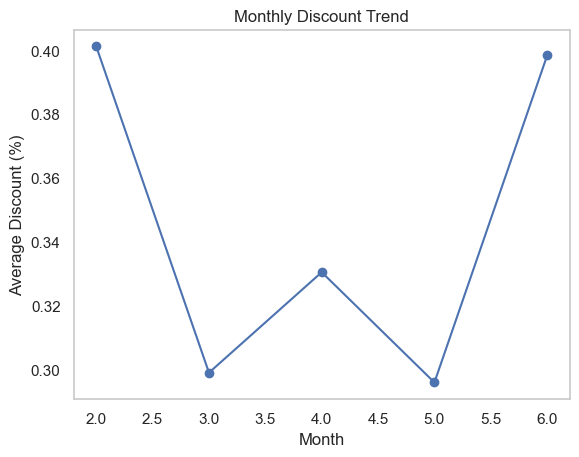

In [1561]:
# 1. Monthly Discount Trend
plt.figure()
plt.plot(monthly_trend['Month'], monthly_trend['corrected_Depth%'], marker='o')
plt.title("Monthly Discount Trend")
plt.xlabel("Month")
plt.ylabel("Average Discount (%)")
plt.grid()
plt.show()

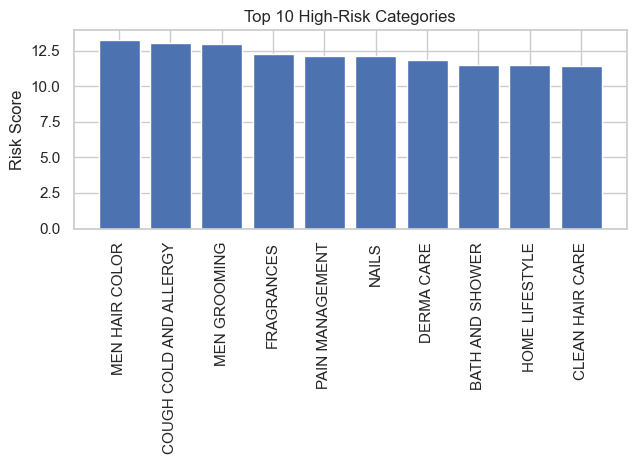

In [1562]:
# 2. Top 10 Risky Categories
top_risk = category_analysis.head(10)

plt.figure()
plt.bar(top_risk['Category'], top_risk['Promo_Risk_Score'])
plt.title("Top 10 High-Risk Categories")
plt.xticks(rotation=90)
plt.ylabel("Risk Score")
plt.tight_layout()
plt.show()


RECOMMENDATIONS:


1. Shift from Volume-Driven to Profit-Driven Promotions
Introduce margin guardrails for all campaigns
Avoid deep discounting without clear ROI justification
2. Optimize Discount Depth
Identify and enforce optimal discount brands per category
Reduce unnecessary over-discounting
3. Prioritize High-Margin Categories
Focus promotions on products that:
Can absorb discounts
Drive profitable basket expansion
4. Implement Promotion Performance Dashboard
Track in real-time:
Revenue vs margin impact
Discount efficiency
Category performance
5. Move Toward Data-Driven Personalization (Future Scope)
Transition from blanket promotions to:
Targeted offers

